In [1]:
import numpy as np
np.float = float
np.int = int 
import nanonispy2 as nap2
import nanonispy 
import nanonispyfit 
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd 
import pickle 
import cv2 
import argparse


from skimage.color import rgb2gray, label2rgb
from skimage.feature import blob_log, peak_local_max
from skimage import exposure, filters
from skimage.util import img_as_float
from skimage.morphology import erosion, dilation, opening, closing, disk, square, white_tophat
from skimage.filters import threshold_otsu
from skimage.segmentation import clear_border, watershed
from skimage.measure import label, regionprops, find_contours
from skimage.restoration import (
    denoise_tv_chambolle,
    denoise_bilateral,
    denoise_wavelet,
    estimate_sigma,
)
from skimage import img_as_float
from skimage.util import random_noise
from skimage.metrics import peak_signal_noise_ratio


from scipy import misc # denoising the imaage 
from scipy import ndimage as ndi

from PIL import Image

C:\Users\andre\AppData\Local\Temp\ipykernel_49892\3887855660.py:34: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  from scipy import misc # denoising the imaage


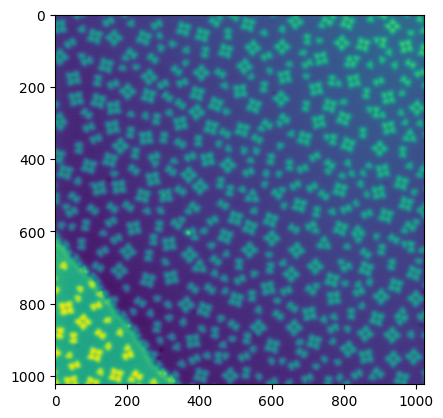

In [2]:
import os 

# Looping through the folder, and load the sxm image 
imgs = []

for files in os.listdir('Stetsovych Helicene'):
    scan = nanonispy.read.Scan(f'Stetsovych Helicene/{files}')
    im = scan.signals["Z"]["backward"]
    im = nanonispyfit.plane_fit_2d(im)    
    imgs.append(im)

    
img_3 = imgs[2]
plt.imshow(imgs[2])

## Preprocessing 

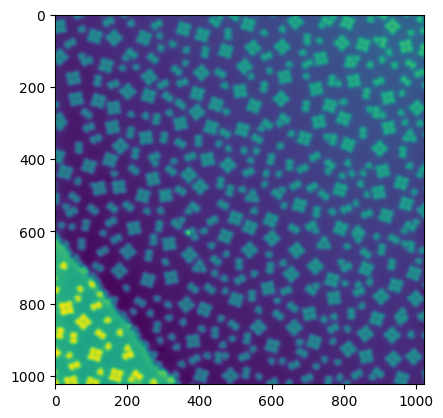

In [3]:
def denoise_images(im):
    """
    Uses cv2 to denoise image
    
    fast NlMeansDenoising 
    
    Making the image clearer, less blurry. 
    Args:
        im: The image to be processed, grayscaled
    Return: 
        denoised_im: processed image 
    """
    im_float = img_as_float(im)
    im_rescaled = exposure.rescale_intensity(im_float, in_range='image', out_range=(0, 1))
    im_8u = (im_rescaled * 255).astype(np.uint8)
    denoised_im = cv2.fastNlMeansDenoising(im_8u, h=10)
    return denoised_im 

def CCL(im, plot=True):
    """
    Uses Connected Component Labels to make the molecules more clear 
    Args: 
        im: The image to be implemented, binary and gray scale
    
    """
    
    im_norm = cv2.normalize(im, None, 0, 255, cv2.NORM_MINMAX)
    im_uint8 = im_norm.astype(np.uint8)
    
   # Otsu threshold
    _, binary = cv2.threshold(im_uint8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    binary_01 = (binary > 0).astype(np.uint8)
    
    (numLabels, Labels, stats, centroids) = cv2.connectedComponentsWithStats(binary_01, 4, cv2.CV_32S)


    # Assign random colors to each component (background = black)
    output = np.zeros((Labels.shape[0], Labels.shape[1], 3), dtype=np.uint8)
    colors = np.random.randint(0, 255, size=(numLabels, 3), dtype=np.uint8)
    for i in range(1, numLabels):  # skip background
        output[Labels == i] = colors[i]
    
    return output
    


img_3 = denoise_images(img_3)

plt.imshow(img_3)


## Image Processing

Text(0.5, 1.0, 'Lapalace')

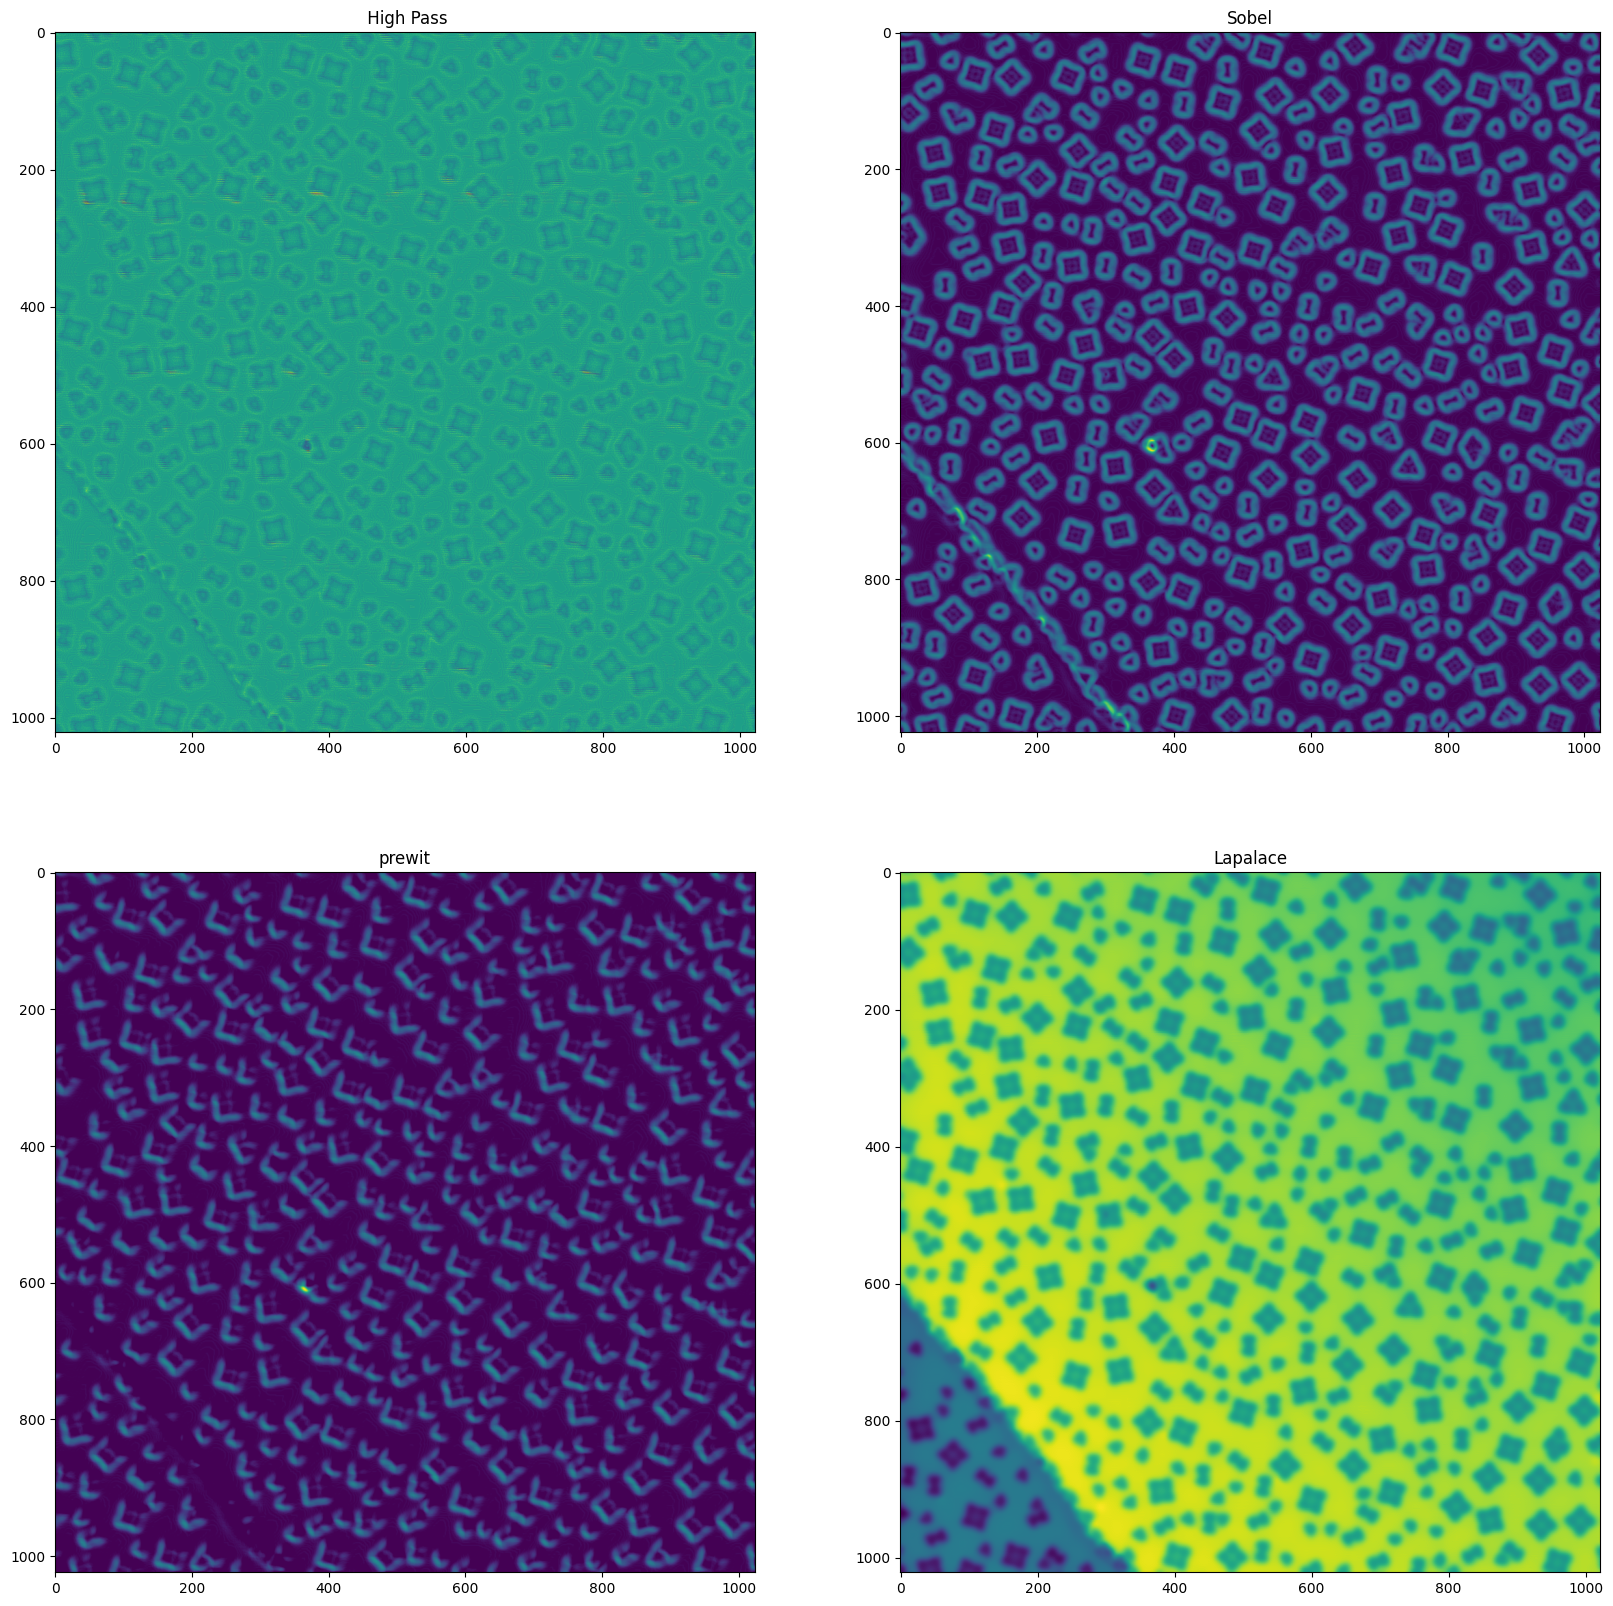

In [17]:
from scipy import signal


# --- Using First order Derivative 
def edge_detection_highpass(im):
    im_blur = cv2.GaussianBlur(im, (5, 5), 1)
    
    filt = 1./9.*np.array([
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]
    ])

    convolved = signal.convolve2d(im, filt, mode='valid')
    
    diff = convolved - im[1:-1, 1:-1]
    
    return diff 


def edge_detection_Sobel(im):
    sobelx = cv2.Sobel(im, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(im, cv2.CV_64F, 0, 1, ksize=3)
    
    gradient_mag = cv2.magnitude(sobelx, sobely)
    gradient_mag = cv2.convertScaleAbs(gradient_mag)
    
    return gradient_mag

def edge_detection_Prewitt(im):
    
    # Turning into gray-scale
    if len(im.shape) == 3:
        gray = (0.2989*im[:,:,0] + 0.5870*im[:,:,1] + 0.1140*im[:,:,2])
    else:
        gray = im.copy()
        
    im_gaussian = cv2.GaussianBlur(gray, (3, 3), 0)
    
    kernelPrewittx = np.array([
        [1, 1, 1],
        [0, 0, 0],
        [-1, -1, -1]
    ])
    
    kernelPrewitty = np.array([
        [-1, 0, 1],
        [-1, 0, 1],
        [-1, 0, 1]
    ])
    
    img_prewittx = cv2.filter2D(im_gaussian, -1, kernelPrewittx)
    img_prewitty = cv2.filter2D(im_gaussian, -1, kernelPrewitty)
    
    img_prewitt = img_prewittx + img_prewitty
    
    img_prewitt_uint8 = cv2.convertScaleAbs(img_prewitt)
    
    return img_prewitt_uint8

# Second Derivative Kernel 
def edge_detection_laplacian(im):
    im_blur = cv2.GaussianBlur(im, (5, 5), 1)
    
    filt = np.array([
        [0, -1, 0],
        [-1, 4, -1],
        [0, -1, 0]
    ])

    convolved = signal.convolve2d(im, filt, mode='valid')
    
    diff = convolved - im[1:-1, 1:-1]
    
    return diff 

    
# --- Drawing Contours --- 
def CV_drawContours(im):
    if len(im.shape) == 3:
        gray = (0.2989*im[:,:,0] + 0.5870*im[:,:,1] + 0.1140*im[:,:,2])
    else:
        gray = im.copy()
        
    if gray.dtype != np.uint8:
        gray = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # Threshold (to get binary image)
    _, thresh = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)

    # Find contours
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    contour_img = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    # Draw contours on a copy of original image
    NUM_MOL = len(contours)

    cv2.drawContours(contour_img, contours, -1, (0, 0, 255), 3)  
    
    return NUM_MOL, contour_img 



im_3_edge_highpass = edge_detection_highpass(img_3)
im_3_edge_sobel = edge_detection_Sobel(img_3)
im_3_edge_prewit = edge_detection_Prewitt(img_3)
im_3_edge_lapalace = edge_detection_laplacian(img_3)


fig, axes = plt.subplots(2, 2, figsize=(20, 20))



axes[0, 0].imshow(im_3_edge_highpass)
axes[0, 0].set_title(' High Pass')

axes[0, 1].imshow(im_3_edge_sobel)
axes[0, 1].set_title('Sobel')

axes[1, 0].imshow(im_3_edge_prewit)
axes[1, 0].set_title('prewit')

axes[1, 1].imshow(im_3_edge_lapalace)
axes[1, 1].set_title('Lapalace')



Text(0.5, 1.0, 'Lapalace')

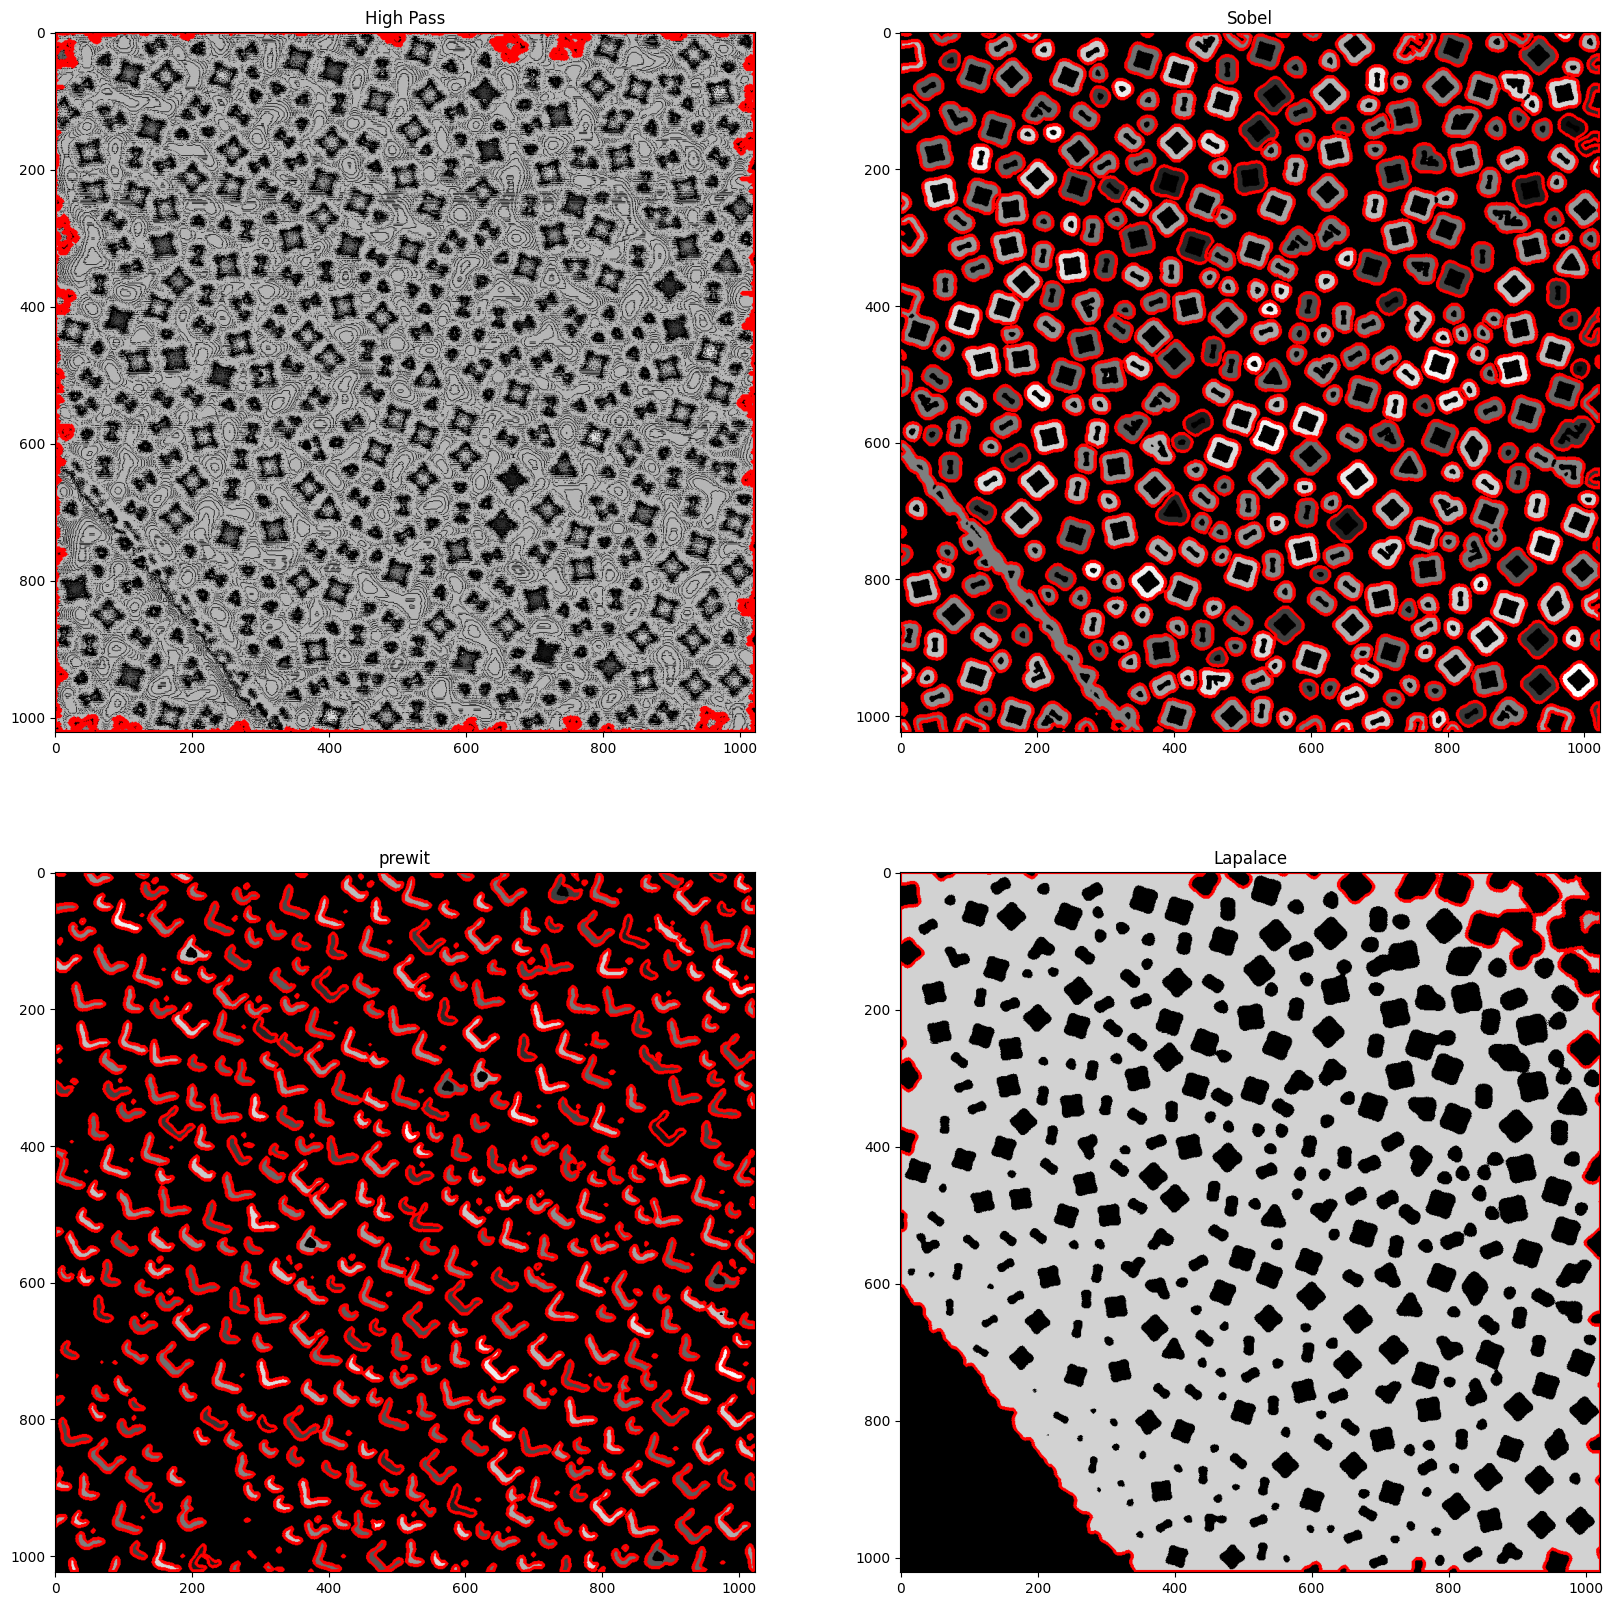

In [18]:
Sobel_CCL = CCL(im_3_edge_sobel, plot=False)
Prewit_CCL = CCL(im_3_edge_prewit, plot=False)
Highpass_CCL = CCL(im_3_edge_highpass, plot=False)
Lapalace_CCL = CCL(im_3_edge_lapalace, plot=False)

num_sobel, contour_sobel = CV_drawContours(Sobel_CCL)
num_prewit, contour_prewit = CV_drawContours(Prewit_CCL)
num_highpass, contour_highpass = CV_drawContours(Highpass_CCL)
num_lapalace, contour_lapalace = CV_drawContours(Lapalace_CCL)


fig, axes = plt.subplots(2, 2, figsize=(20, 20))

axes[0, 0].imshow(cv2.cvtColor(contour_highpass, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('High Pass')

axes[0, 1].imshow(cv2.cvtColor(contour_sobel, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title('Sobel')

axes[1, 0].imshow(cv2.cvtColor(contour_prewit, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title('prewit')

axes[1, 1].imshow(cv2.cvtColor(contour_lapalace, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title('Lapalace')

Out of these three methods, we see that Sobel functions most effectively. 

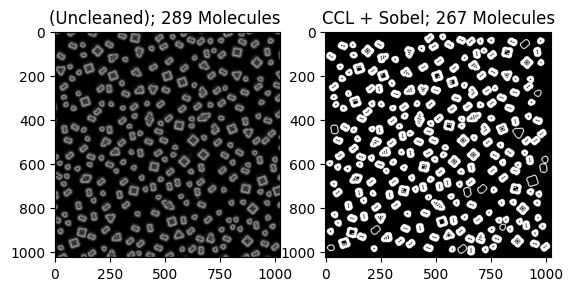

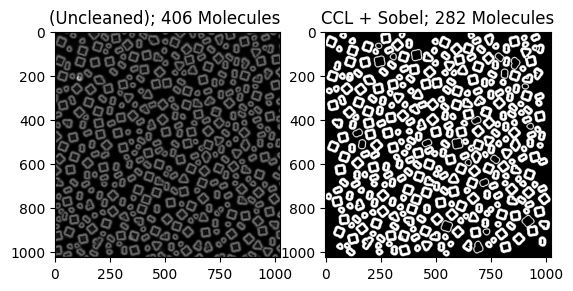

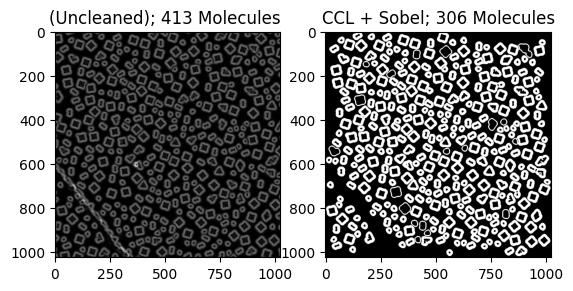

In [25]:
from scipy import ndimage
# Using Sobel edge detection method to determine 

# --- Image cleaning --- 
def clean_im(im):
    if len(im.shape) == 3:
        im = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    im = im.astype(np.uint8)
    
    _, binary = cv2.threshold(im, 50, 255, cv2.THRESH_BINARY)
    label_im, num_labels = ndimage.label(binary)
    
    mask = np.zeros_like(label_im, dtype=bool)
    mask[0, :] = True 
    mask[-1, :] = True 
    mask[:, 0] = True
    mask[:, -1] = True
    
    border_labels = np.unique(label_im[mask])
    
    for b in border_labels:
        label_im[label_im == b] = 0
        
    clean = np.where(label_im > 0, 255, 0).astype(np.uint8)
    clean = cv2.morphologyEx(clean, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))

    
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(clean, connectivity=8)
    
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] < 50:
            clean[labels == i] = 0
    
    return num_labels ,clean 

processed_images = list()

for img in imgs: 
    # 1. Denoise the image
    img = denoise_images(img)
    # 2. Use edge_detection_sobel
    sobel = edge_detection_Sobel(img)
    # 3. Apply CCL 
    sobel_CCL = CCL(sobel, plot=False)
    NUM_MOL, contour_img = CV_drawContours(sobel_CCL)
    # 4. Clean image 
    num_labels, clean = clean_im(contour_img)
    processed_images.append(clean)
    
    fix, ax = plt.subplots(1, 2)
    ax[0].imshow(sobel, cmap='gray')
    ax[0].set_title(f'(Uncleaned); {NUM_MOL} Molecules ')
    
    ax[1].imshow(cv2.cvtColor(clean, cv2.COLOR_BGR2RGB))
    ax[1].set_title(f'CCL + Sobel; {num_labels} Molecules')

In [28]:
import os 
folder = "Stetsovych_Helicene_PROCESSED"

os.makedirs(folder, exist_ok=True)
# These are pngs
for i, image in enumerate(processed_images):
    filename = os.path.join(folder, f"image_{list(os.listdir('Stetsovych Helicene'))[i]}.png")
    cv2.imwrite(filename, image)